In [1]:
import os
import glob
import numpy as np
import pandas as pd
import pickle
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

from scipy import ndimage
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics import auc
from scipy import stats
import statsmodels.formula.api as smf
import scipy.signal as sig
import quantities as pq

import scipy.stats as sstat
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import mixedlm

sns.set_context('poster')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# import Python3_OpenOE_AC_map_functions_v1_08_30s as oem
import mz_LFP_functions as mz_LFP

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# for publication quality plots
def set_pub_plots(pal=sns.blend_palette(["gray","crimson", 'cyan', 'magenta', 'purple'  ],5)):
    sns.set_style("white")
    sns.set_palette(pal)
    sns.set_context("poster", font_scale=1.5, rc={"lines.linewidth":2.5, "axes.linewidth":2.5, 'figure.facecolor': 'white'}) 
    sns.set_style("ticks", {"xtick.major.size":8, "ytick.major.size":8})
    plt.rcParams['axes.linewidth']=2.5

rc_pub={'font.size':25, 'axes.labelsize':25, 'legend.fontsize':25.0, 
    'axes.titlesize':25, 'xtick.labelsize':25, 'ytick.labelsize':25, 
    'axes.linewidth':2.5, 'lines.linewidth':2.5,
    'xtick.color':'black', 'ytick.color':'black', 'axes.edgecolor': 'black', 'axes.labelcolor':'black', 'text.color':'black'}
# to restore the defaults, call plt.rcdefaults() 

#set_pub_bargraphs()
set_pub_plots()

# Load some necessary variables

In [3]:
insert_depth = 3100  #change this as appropriate

sp_bw_ch = 20/2

surface_ch = np.round(insert_depth/sp_bw_ch)
V1_hip_ch = np.round((insert_depth-1000)/sp_bw_ch)
Hip_thal_ch = np.round((insert_depth-1000-1200)/sp_bw_ch)

CA1_DG_ch = np.round((insert_depth-1000-600)/sp_bw_ch)

print(surface_ch, V1_hip_ch, Hip_thal_ch, CA1_DG_ch)

310.0 210.0 90.0 150.0


In [4]:
samples_tr = 7350 #this is based on the shortest #samples in a trial
sr = 2500
n_chan = 384
rec_length = 3.0 #how long is the arduino triggered?

---

# First, load in the .npy arrays and CC_ls
These were creaded and saved using the "1_saving_LFP_arrays" jupyter notebook

In [5]:
all_rew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_rew.npy")
all_rew2_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_rew2.npy")
all_unrew_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_all_unrew.npy")
all_novel_arr = np.load(r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\novel_all_rew.npy")

In [6]:
pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\1sec_cc_ls"

open_file = open(pkl_file, "rb")
CC_ls = pickle.load(open_file)
open_file.close()

len(CC_ls)

18

In [7]:
nov_pkl_file = r"D:\mz_Data\saved_dfs\02_wtfx_behavior\reward\lfps\novel_cc_ls"

open_file = open(nov_pkl_file, "rb")
nov_CC_ls = pickle.load(open_file)
open_file.close()

len(nov_CC_ls)

16

In [8]:
print('rew: {0}'.format(all_rew_arr.shape))
print('rew2: {0}'.format(all_rew2_arr.shape))
print('unrew: {0}'.format(all_unrew_arr.shape))
print('novel: {0}'.format(all_novel_arr.shape))

rew: (18, 384, 7350)
rew2: (18, 384, 7350)
unrew: (18, 384, 7350)
novel: (16, 384, 7350)


---

# Hippocampus results

In [9]:
def V1HPC(data_array, CC_ls):
    wt = []
    fx = []
    for i in range(data_array.shape[0]):
        if (CC_ls[i] == "CC082263") | (CC_ls[i] == "CC067489") | (CC_ls[i] == "CC082260") | (CC_ls[i] == "CC084621"):
            wt.append(data_array[i])
        elif (CC_ls[i] == "CC082257") | (CC_ls[i] == "CC067431") | (CC_ls[i] == "CC067432") | (CC_ls[i] == "CC082255"):
            fx.append(data_array[i])
    wt_arr = np.array(wt)
    fx_arr = np.array(fx)
    return wt_arr, fx_arr

In [13]:


v1_ch = 260
hpc_ch = 110



---

In [33]:
scenario = 'novel'

if scenario == "rew":
    plt_title = "Go+"
    wt_all, fx_all = V1HPC(all_rew_arr, CC_ls)
    wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)
if scenario == "rew2":
    plt_title = "Go-"
    wt_all, fx_all = V1HPC(all_rew2_arr, CC_ls)
    wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)
if scenario == "unrew":
    plt_title = "No-Go"
    wt_all, fx_all = V1HPC(all_unrew_arr, CC_ls)
    wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)
if scenario == "novel":
    plt_title = "Novel"
    wt_all, fx_all = V1HPC(all_novel_arr, CC_ls)
    wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)

# plot lfp across entire probe

In [66]:
# fig = plt.figure(figsize=(6,8))

# colormap='viridis'
# plt_labels = [0,0.5*sr,1*sr,1.5*sr,2*sr,2.5*sr]

# lfp_wt = wt_mean * 1E-3 * pq.mV #helps to keep the colorbar tidy and clean
# lfp_fx = fx_mean * 1E-3 * pq.mV #helps to keep the colorbar tidy and clean
# cbar_scale = abs(lfp_wt).max()

# im1 = plt.imshow(lfp_wt, origin='lower', vmin=(-0.2*pq.mV), vmax=(0.2*pq.mV), 
#                  cmap=colormap, interpolation='nearest', aspect='auto')
# plt.title('WT - '+scenario)
# # im1 = plt.imshow(lfp_fx, origin='lower', vmin=(-0.2*pq.mV), vmax=(0.2*pq.mV), 
# #                  cmap=colormap, interpolation='nearest', aspect='auto')
# # plt.title('FX - '+scenario)

# plt.axhline(y=v1_ch, color='pink')
# plt.axhline(y=hpc_ch, color='pink')
# plt.ylim([50,310])
# plt.yticks(ticks=[50,100,150,200,250,300], labels=[-2.5,-2,-1.5,-1,-0.5,0])
# plt.xticks(ticks=[0,1250,2500,3750,5000,6250], labels=[0,0.5,1.0,1.5,2.0,2.5])
# plt.ylabel('Depth (mm)')
# plt.xlabel('Time (s)')

# cbar_ax = fig.add_axes([1, 0.15, 0.04, 0.7])
# cbar = fig.colorbar(im1, cax=cbar_ax)
# cbar.set_label('LFP (mV)')

# # Change the end of this next line with a new file name!!
# # out_path = r"C:\Users\AChub_Lab\Desktop\temp_hpc_plots\wt_"+scenario+"_imshow.pdf"
# # plt.savefig(out_path, transparent=True)

# plt.show()

# plot veps of v1 and hpc channel

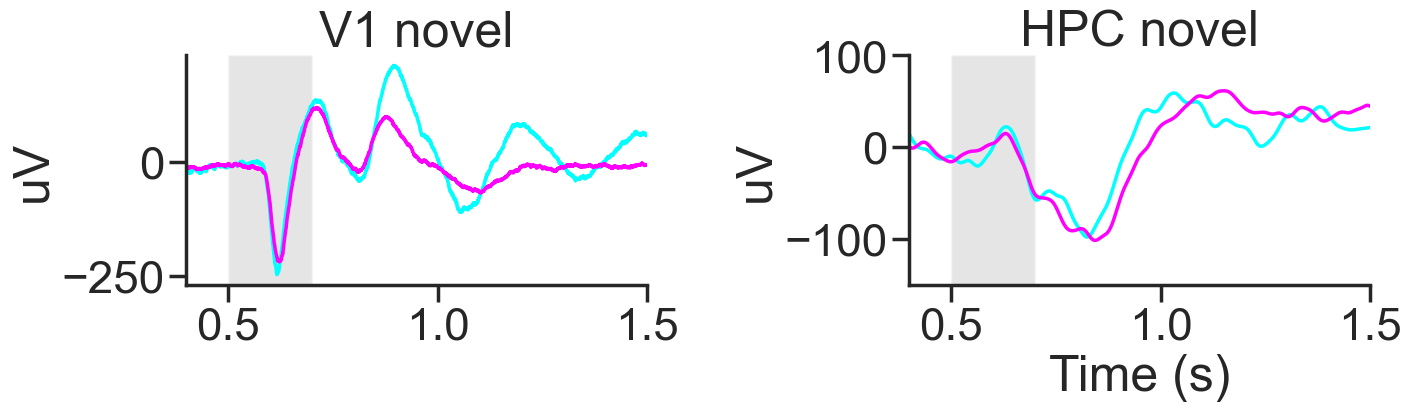

In [34]:
fig = plt.figure(figsize=(15,5))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122, sharex=ax1)

time_axis = np.linspace(0, wt_mean.shape[1]/sr, wt_mean.shape[1])
ax1.plot(time_axis, wt_mean[v1_ch], label='WT', color='cyan') #un-filtered
ax1.plot(time_axis, fx_mean[v1_ch], label='FX', color='magenta') #un-filtered
ax1.set_title('V1 '+scenario)

ax2.plot(time_axis, ndimage.gaussian_filter(wt_mean[hpc_ch], sigma=30), label='WT', color='cyan') #un-filtered, but with a gaussian to smooth it
ax2.plot(time_axis, ndimage.gaussian_filter(fx_mean[hpc_ch], sigma=30), label='FX', color='magenta') #un-filtered, but with a gaussian to smooth it
ax2.set_title('HPC '+scenario)

# ax1.set_xticks([0,0.5,1.0,1.5,2.0,2.5,3.0])
ax2.set_xlabel('Time (s)')
ax1.set_ylabel('uV')
ax2.set_ylabel('uV')
ax2.set_ylim([-150,100])
ax2.set_yticks([-100,0,100])
ax2.set_xlim([0.4,1.5])

ax1.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')
ax2.axvspan(0.5, 0.7, alpha=0.2, facecolor='grey')

sns.despine()
plt.tight_layout()
# Change the end of this next line with a new file name!!
# out_path = r"C:\Users\AChub_Lab\Desktop\temp_figures\lfps\veps_"+scenario+"gaussFilt.pdf"
# plt.savefig(out_path, transparent=True)

plt.show()

# FFT of the HPC vep plotted above

In [68]:
def get_lfp_fft(lfp_ch_array):
    freq = np.arange(lfp_ch_array.shape[0]) / lfp_ch_array.shape[0] * sr
    freq = freq[:freq.shape[0]//2]
    f = np.fft.fft(lfp_ch_array)
    magnitude_spectrum = (np.abs(f)[:freq.shape[0]])
    return freq, magnitude_spectrum

# now quantify the fft for each mouse

In [190]:
def get_FFT_dataframes(wt_all, fx_all, scenario, bands = [[2,4],[4,8],[8,12],[12,30],[30,70]], scale_val=1000, sig=2):
    # run for all wt mice
    lfp_auc, wt_ALLunitsFFT = [], []
    for idx, et in enumerate(wt_all):
        fft_freq, fft_amp = get_lfp_fft(et[hpc_ch])
        LFP1df = pd.DataFrame({'freq':fft_freq, 'amp':ndimage.gaussian_filter(fft_amp, sigma=sig)/scale_val, 'et':idx, 'stim':scenario, 'group':'WT', 'region':'HPC'})
        wt_ALLunitsFFT.append(LFP1df)
        auc_val, band_val, peak_val, mean_val = [], [], [], []
        for ran in bands:
            lower = fft_freq.searchsorted(ran[0], 'left')
            upper = fft_freq.searchsorted(ran[1], 'right') -1
            val = auc(fft_freq[lower:upper], ndimage.gaussian_filter(fft_amp[lower:upper], sigma=sig))
            auc_val.append(val/scale_val)
            band_val.append(str(ran))
            peak_val.append(np.max(ndimage.gaussian_filter(fft_amp[lower:upper], sigma=sig))/scale_val)
            mean_val.append(np.mean(ndimage.gaussian_filter(fft_amp[lower:upper], sigma=sig))/scale_val)
        lfp_auc.append(pd.DataFrame({'band':band_val, 'auc':auc_val, 'peak':peak_val, 'mean':mean_val, 'et':idx, 'stim':scenario, 'group':'WT', 'region':'HPC'}))
    wt_lfp_auc = pd.concat(lfp_auc)
    wt_lfp_FFT = pd.concat(wt_ALLunitsFFT)
    #run for all fx mice
    lfp_auc, fx_ALLunitsFFT = [], []
    for idx, et in enumerate(fx_all):
        fft_freq, fft_amp = get_lfp_fft(et[hpc_ch])
        LFP1df = pd.DataFrame({'freq':fft_freq, 'amp':ndimage.gaussian_filter(fft_amp, sigma=sig)/scale_val, 'et':idx, 'stim':scenario, 'group':'FX', 'region':'HPC'})
        fx_ALLunitsFFT.append(LFP1df)
        auc_val, band_val, peak_val, mean_val = [], [], [], []
        for ran in bands:
            lower = fft_freq.searchsorted(ran[0], 'left')
            upper = fft_freq.searchsorted(ran[1], 'right') -1
            val = auc(fft_freq[lower:upper], ndimage.gaussian_filter(fft_amp[lower:upper], sigma=sig))
            auc_val.append(val/scale_val)
            band_val.append(str(ran))
            peak_val.append(np.max(ndimage.gaussian_filter(fft_amp[lower:upper], sigma=sig))/scale_val)
            mean_val.append(np.mean(ndimage.gaussian_filter(fft_amp[lower:upper], sigma=sig))/scale_val)
        lfp_auc.append(pd.DataFrame({'band':band_val, 'auc':auc_val, 'peak':peak_val, 'mean':mean_val, 'et':idx, 'stim':scenario, 'group':'FX', 'region':'HPC'}))
    fx_lfp_auc = pd.concat(lfp_auc)
    fx_lfp_FFT = pd.concat(fx_ALLunitsFFT)
    #concatenate the wt and fx dfs together
    all_lfp_auc = pd.concat([wt_lfp_auc, fx_lfp_auc])
    ALL_lfp_FFT = pd.concat([wt_lfp_FFT, fx_lfp_FFT])
    return all_lfp_auc, ALL_lfp_FFT

In [191]:


hpc_ch = 180



In [192]:
all_lfp_situ, all_lfp_fft = [], []
for scenario in ['rew','rew2','unrew','novel']:
    if scenario == "rew":
        plt_title = "Go+"
        wt_all, fx_all = V1HPC(all_rew_arr, CC_ls)
        wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)
    if scenario == "rew2":
        plt_title = "Go-"
        wt_all, fx_all = V1HPC(all_rew2_arr, CC_ls)
        wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)
    if scenario == "unrew":
        plt_title = "No-Go"
        wt_all, fx_all = V1HPC(all_unrew_arr, CC_ls)
        wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)
    if scenario == "novel":
        plt_title = "Novel"
        wt_all, fx_all = V1HPC(all_novel_arr, CC_ls)
        wt_mean, fx_mean = wt_all.mean(axis=0), fx_all.mean(axis=0)

    all_lfp_auc, ALL_lfp_FFT = get_FFT_dataframes(wt_all, fx_all, scenario)
    all_lfp_situ.append(all_lfp_auc) #append all scenarios together
    all_lfp_fft.append(ALL_lfp_FFT)
    
all_lfp_situ = pd.concat(all_lfp_situ)
all_lfp_fft = pd.concat(all_lfp_fft)

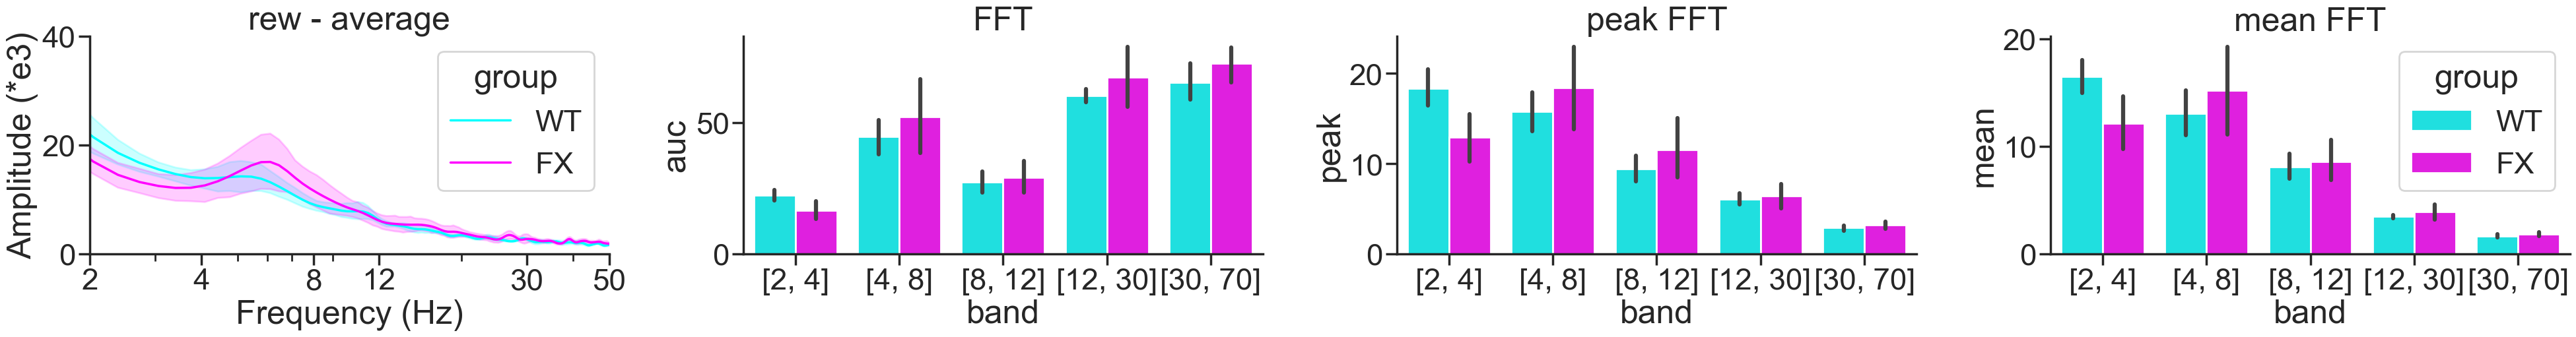

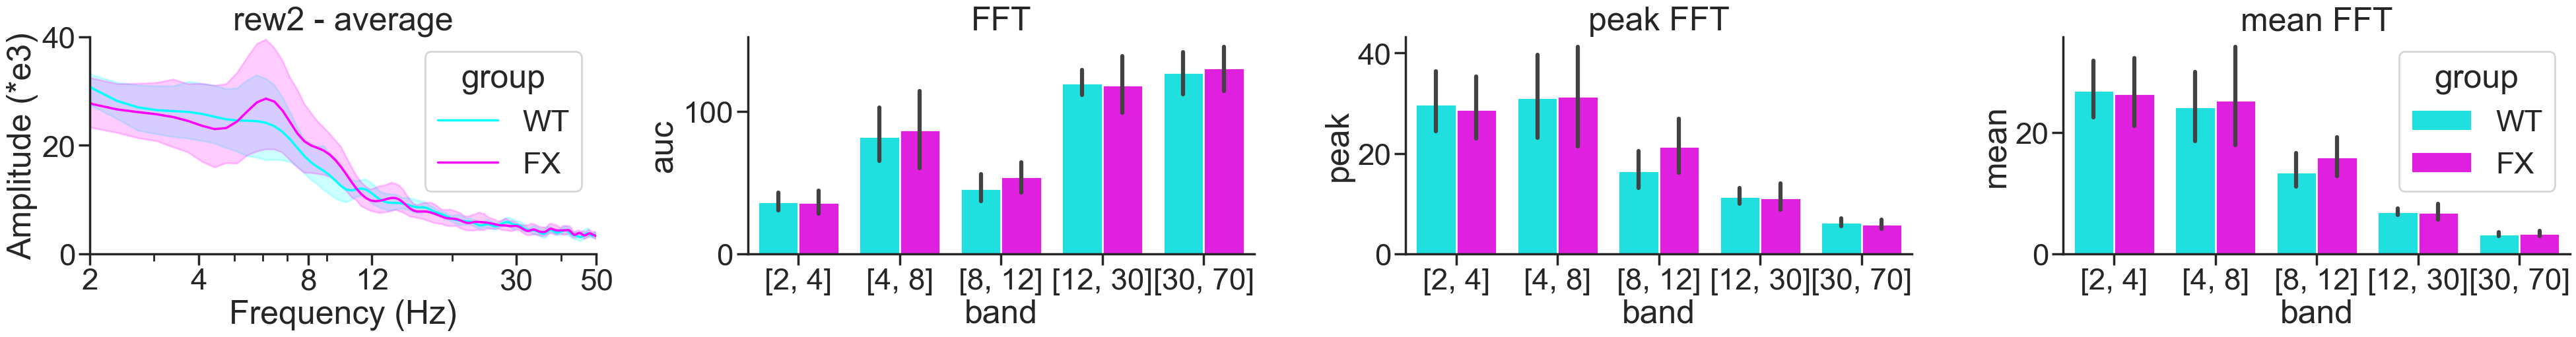

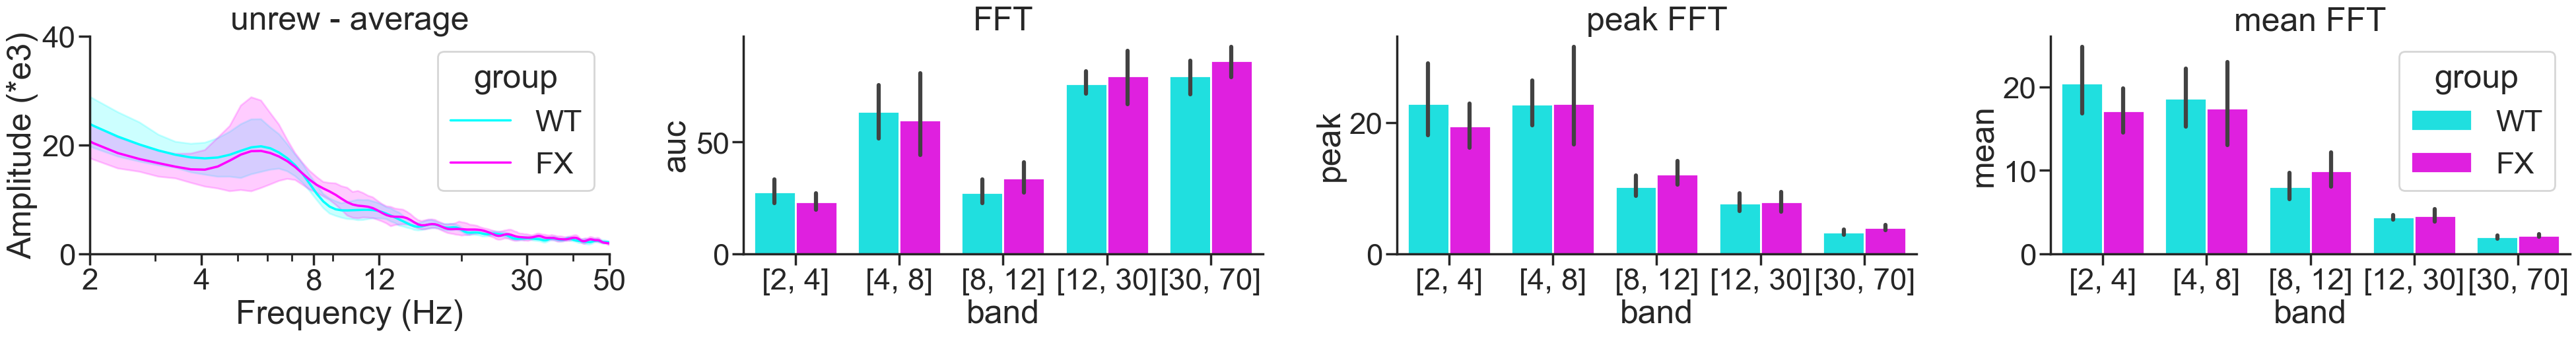

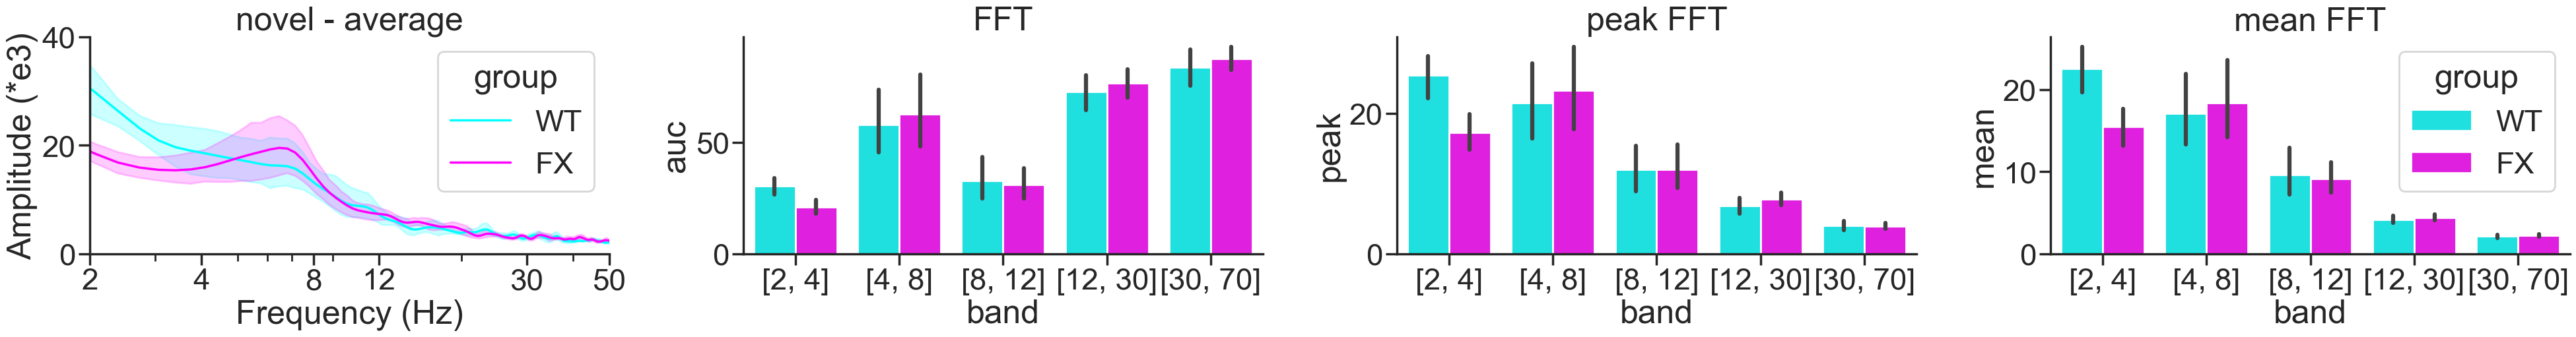

In [195]:
for scenario in ['rew','rew2','unrew','novel']:
    fig,ax = plt.subplots(1,4, figsize=(40,6))
    sns.lineplot(x='freq', y='amp', estimator='mean', data=all_lfp_fft[(all_lfp_fft.stim==scenario)&(all_lfp_fft.region=='HPC')],
                hue='group', hue_order=['WT','FX'], palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[0])
    ax[0].set(xlabel='Frequency (Hz)', ylabel='Amplitude (*e3)')
    ax[0].set_xscale('log')
    ax[0].set_xticks([2,4,8,12,30,50])
    ax[0].set_xticklabels([2,4,8,12,30,50])
    ax[0].set_xlim([2,50])
    ax[0].set_ylim([0,40])
    ax[0].set_title(f'{scenario} - average')
    sns.barplot(data=all_lfp_situ[all_lfp_situ.stim == scenario], x='band', y='auc', hue='group', hue_order=['WT','FX'], palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[1])
    ax[1].set_title(f'FFT')
    ax[1].legend_.remove()
    sns.barplot(data=all_lfp_situ[all_lfp_situ.stim == scenario], x='band', y='peak', hue='group', hue_order=['WT','FX'], palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[2])
    ax[2].set_title(f'peak FFT')
    ax[2].legend_.remove()
    sns.barplot(data=all_lfp_situ[all_lfp_situ.stim == scenario], x='band', y='mean', hue='group', hue_order=['WT','FX'], palette={'WT':'cyan', 'FX':'magenta'}, ax=ax[3])
    ax[3].set_title(f'mean FFT')
    sns.despine()
    plt.tight_layout()
    # Change the end of this next line with a new file name!!
    # out_path = rf"C:\Users\AChub_Lab\Desktop\temp_figures\allFFT_{scenario}_Quant_AUCpeakMean.pdf"
    # plt.savefig(out_path, transparent=True)
    plt.show()

In [198]:
# test for normality on the data
import pingouin as pg
# ? pg.normality
for item in ['auc','peak','mean']:
    print(f'--------------- {item} ---------------')
    for st,df in all_lfp_situ.groupby(['region','stim','band']):
        print(st)
        print(pg.normality(data=df, dv=item, group='group')) # Shapiro-Wilk test for normality

--------------- auc ---------------
('HPC', 'novel', '[12, 30]')
              W      pval  normal
group                            
WT     0.824707  0.052280    True
FX     0.920223  0.431674    True
('HPC', 'novel', '[2, 4]')
              W      pval  normal
group                            
WT     0.922035  0.446594    True
FX     0.925566  0.476629    True
('HPC', 'novel', '[30, 70]')
              W      pval  normal
group                            
WT     0.929004  0.507057    True
FX     0.870610  0.152812    True
('HPC', 'novel', '[4, 8]')
              W      pval  normal
group                            
WT     0.857243  0.112697    True
FX     0.891429  0.241289    True
('HPC', 'novel', '[8, 12]')
              W      pval  normal
group                            
WT     0.754484  0.009155   False
FX     0.921626  0.443197    True
('HPC', 'rew', '[12, 30]')
              W      pval  normal
group                            
WT     0.939131  0.543381    True
FX     0.907957

In [133]:
# # run LMM to tet for dependence across groups (only really care about the Intercept p-value)
# for item in ['auc','peak','mean']:
#     print(f'--------------- {item} ---------------')
#     for g,gg in all_lfp_situ.groupby(['region','stim']):
#         numWT = gg[gg.group=='WT'].et.nunique()
#         numFX = gg[gg.group=='FX'].et.nunique()
#         model = mixedlm(formula=f'{item} ~ group', data=gg, groups=gg['band']).fit(method=["lbfgs"]) # for testing the FFT AUC
#         print(f'{g} # WT mice: {numWT}')
#         print(f'{g} # FX mice: {numFX}')
#         print(model.summary())
#         print(model.pvalues, end='\n\n')

In [134]:
# #tukey HSD to compare pairwise within each band for each region
# for item in ['auc','peak','mean']:
#     print(f'--------------- {item} ---------------')
#     for st,df in all_lfp_situ.groupby(['region','stim','band']):
#         tukey = pairwise_tukeyhsd(endog=df[item], groups=df['group'], alpha=0.05)
#         pval = round(tukey.pvalues[0],5)
#         print(f"{st} -- WT,FX: {df[df['group']=='WT'].et.nunique()},{df[df['group']=='FX'].et.nunique()} -- pvals: {pval} -- ",
#               '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns')))

In [199]:
#Mann Whitney U to compare pairwise within each band for each region
for item in ['auc','peak','mean']:
    print(f'--------------- {item} ---------------')
    for st,df in all_lfp_situ.groupby(['region','stim','band']):
        U,pval = sstat.mannwhitneyu(df[df.group=='WT'][item].values, df[df.group=='FX'][item].values)
        print(f"{st} -- WT,FX: {df[df['group']=='WT'].et.nunique()},{df[df['group']=='FX'].et.nunique()} -- pvals: {round(pval,7)} -- ",
              '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else 'ns')))

--------------- auc ---------------
('HPC', 'novel', '[12, 30]') -- WT,FX: 8,8 -- pvals: 0.3177123 --  ns
('HPC', 'novel', '[2, 4]') -- WT,FX: 8,8 -- pvals: 0.0073187 --  **
('HPC', 'novel', '[30, 70]') -- WT,FX: 8,8 -- pvals: 0.4302181 --  ns
('HPC', 'novel', '[4, 8]') -- WT,FX: 8,8 -- pvals: 0.874643 --  ns
('HPC', 'novel', '[8, 12]') -- WT,FX: 8,8 -- pvals: 1.0 --  ns
('HPC', 'rew', '[12, 30]') -- WT,FX: 10,8 -- pvals: 0.3981278 --  ns
('HPC', 'rew', '[2, 4]') -- WT,FX: 10,8 -- pvals: 0.0233246 --  *
('HPC', 'rew', '[30, 70]') -- WT,FX: 10,8 -- pvals: 0.0998735 --  ns
('HPC', 'rew', '[4, 8]') -- WT,FX: 10,8 -- pvals: 0.6247051 --  ns
('HPC', 'rew', '[8, 12]') -- WT,FX: 10,8 -- pvals: 1.0 --  ns
('HPC', 'rew2', '[12, 30]') -- WT,FX: 10,8 -- pvals: 0.6247051 --  ns
('HPC', 'rew2', '[2, 4]') -- WT,FX: 10,8 -- pvals: 0.9645281 --  ns
('HPC', 'rew2', '[30, 70]') -- WT,FX: 10,8 -- pvals: 0.5047202 --  ns
('HPC', 'rew2', '[4, 8]') -- WT,FX: 10,8 -- pvals: 0.8938642 --  ns
('HPC', 'rew2', '